In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/cleaned/cleaned_online_retail.csv")

In [2]:
df.shape

(392692, 11)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392692 entries, 0 to 392691
Data columns (total 11 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   InvoiceNo        392692 non-null  int64  
 1   StockCode        392692 non-null  object 
 2   Description      392692 non-null  object 
 3   Quantity         392692 non-null  int64  
 4   InvoiceDate      392692 non-null  object 
 5   UnitPrice        392692 non-null  float64
 6   CustomerID       392692 non-null  int64  
 7   Country          392692 non-null  object 
 8   SalesAmount      392692 non-null  float64
 9   InvoiceDateOnly  392692 non-null  object 
 10  Product          392692 non-null  object 
dtypes: float64(2), int64(3), object(6)
memory usage: 33.0+ MB


In [4]:
df.describe()

,InvoiceNo,Quantity,UnitPrice,CustomerID,SalesAmount
count,392692.000000,392692.000000,392692.000000,392692.000000,392692.000000
mean,560590.875047,13.119702,3.125914,15287.843865,22.631500
std,13087.063759,180.492832,22.241836,1713.539549,311.099224
min,536365.000000,1.000000,0.001000,12346.000000,0.001000
25%,549234.000000,2.000000,1.250000,13955.000000,4.950000
50%,561874.000000,6.000000,1.950000,15150.000000,12.450000
75%,572061.000000,12.000000,3.750000,16791.000000,19.800000
max,581587.000000,80995.000000,8142.750000,18287.000000,168469.600000


In [5]:
country_sales = (
    df.groupby("Country")["SalesAmount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

country_sales

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: SalesAmount, dtype: float64

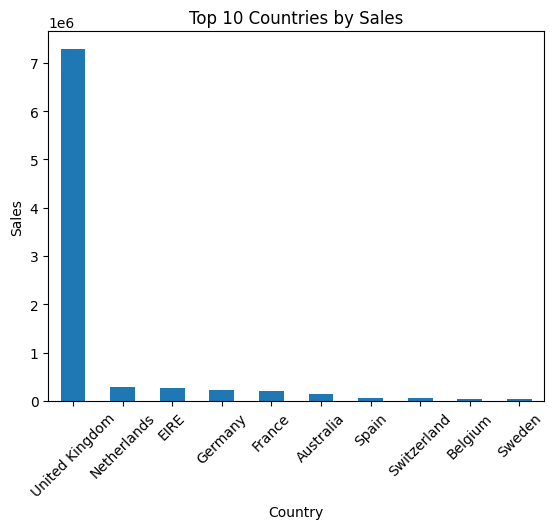

In [6]:
country_sales.plot(kind="bar")

plt.title("Top 10 Countries by Sales")
plt.xlabel("Country")
plt.ylabel("Sales")
plt.xticks(rotation=45)

plt.show()

In [7]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df["YearMonth"] = (
    df["InvoiceDate"]
    .dt.to_period("M")
    .astype(str)
)

In [8]:
monthly_sales = (
    df.groupby("YearMonth")["SalesAmount"]
    .sum()
)

monthly_sales

YearMonth
2010-12     570422.730
2011-01     568101.310
2011-02     446084.920
2011-03     594081.760
2011-04     468374.331
2011-05     677355.150
2011-06     660046.050
2011-07     598962.901
2011-08     644051.040
2011-09     950690.202
2011-10    1035642.450
2011-11    1156205.610
2011-12     517190.440
Name: SalesAmount, dtype: float64

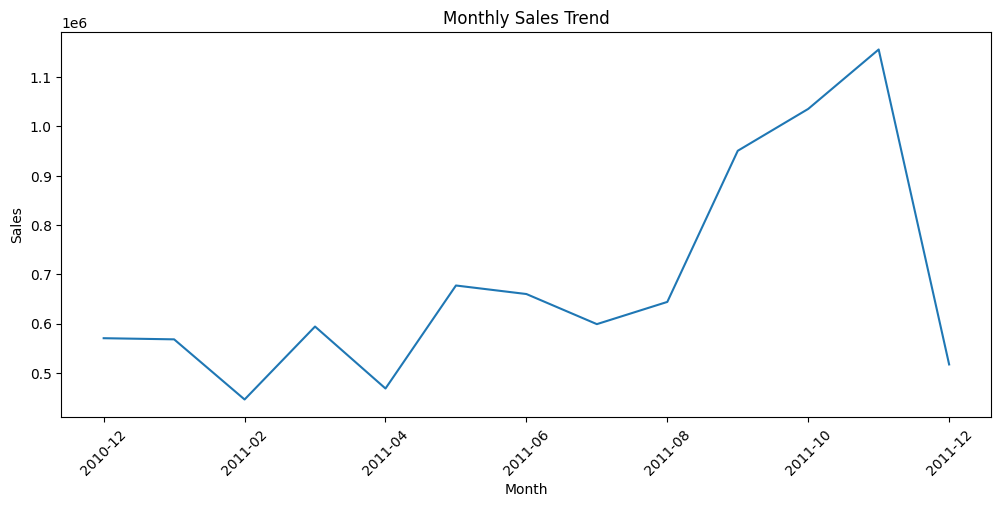

In [9]:
monthly_sales.plot(figsize=(12,5))

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

In [10]:
top_products = (
    df.groupby("Product")["SalesAmount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Product
23843 - PAPER CRAFT , LITTLE BIRDIE            168469.60
22423 - REGENCY CAKESTAND 3 TIER               142264.75
85123A - WHITE HANGING HEART T-LIGHT HOLDER    100392.10
85099B - JUMBO BAG RED RETROSPOT                85040.54
23166 - MEDIUM CERAMIC TOP STORAGE JAR          81416.73
POST - POSTAGE                                  77803.96
47566 - PARTY BUNTING                           68785.23
84879 - ASSORTED COLOUR BIRD ORNAMENT           56413.03
M - Manual                                      53419.93
23084 - RABBIT NIGHT LIGHT                      51251.24
Name: SalesAmount, dtype: float64

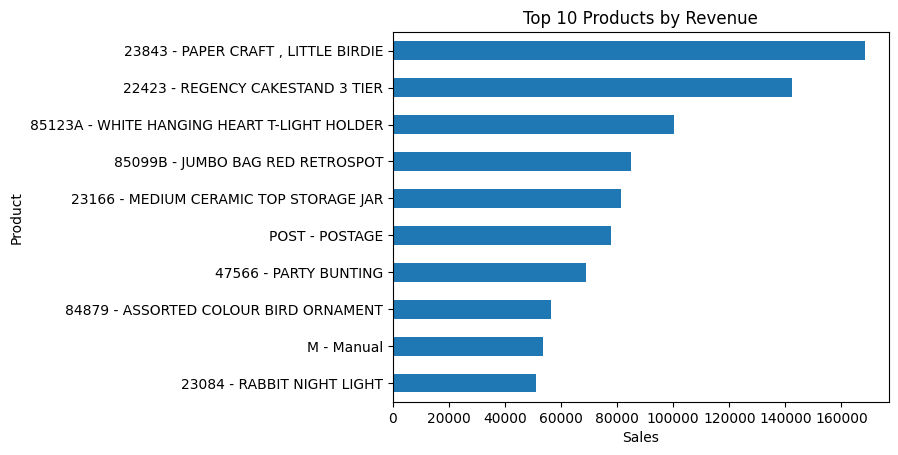

In [11]:
top_products.sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Sales")

plt.show()

In [12]:
top_quantity = (
    df.groupby("Product")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_quantity

Product
23843 - PAPER CRAFT , LITTLE BIRDIE            80995
23166 - MEDIUM CERAMIC TOP STORAGE JAR         77916
84077 - WORLD WAR 2 GLIDERS ASSTD DESIGNS      54319
85099B - JUMBO BAG RED RETROSPOT               46078
85123A - WHITE HANGING HEART T-LIGHT HOLDER    36706
84879 - ASSORTED COLOUR BIRD ORNAMENT          35263
21212 - PACK OF 72 RETROSPOT CAKE CASES        33670
22197 - POPCORN HOLDER                         30919
23084 - RABBIT NIGHT LIGHT                     27153
22492 - MINI PAINT SET VINTAGE                 26076
Name: Quantity, dtype: int64

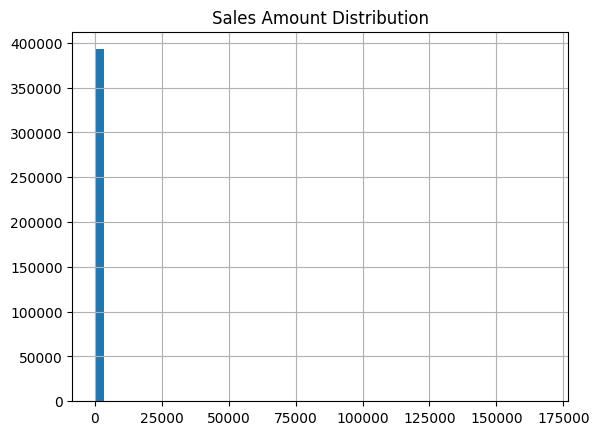

In [13]:
df["SalesAmount"].hist(bins=50)

plt.title("Sales Amount Distribution")

plt.show()

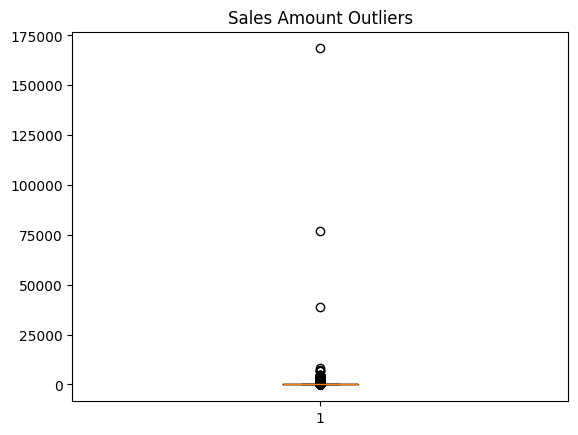

In [14]:
plt.boxplot(df["SalesAmount"])

plt.title("Sales Amount Outliers")

plt.show()


In [15]:
top_customers = (
    df.groupby("CustomerID")["SalesAmount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers

CustomerID
14646    280206.02
18102    259657.30
17450    194390.79
16446    168472.50
14911    143711.17
12415    124914.53
14156    117210.08
17511     91062.38
16029     80850.84
12346     77183.60
Name: SalesAmount, dtype: float64

In [16]:
plt.savefig(
    "../screenshots/monthly_sales.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>